# Import Library and Main Configuration

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import itertools
import json
from prophet.serialize import model_to_json

In [3]:
color_pal = sns.color_palette()
plt.style.use("fivethirtyeight")

In [4]:
pd.set_option('display.max_columns', None)

# EDA

In [5]:
df = pd.read_csv(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\data_RP.csv')
df.head()

,date,price
0,1985-01-01,5205.9538
1,1985-01-02,5158.6730
2,1985-01-03,5104.6378
3,1985-01-04,5118.9909
4,1985-01-07,5036.2495


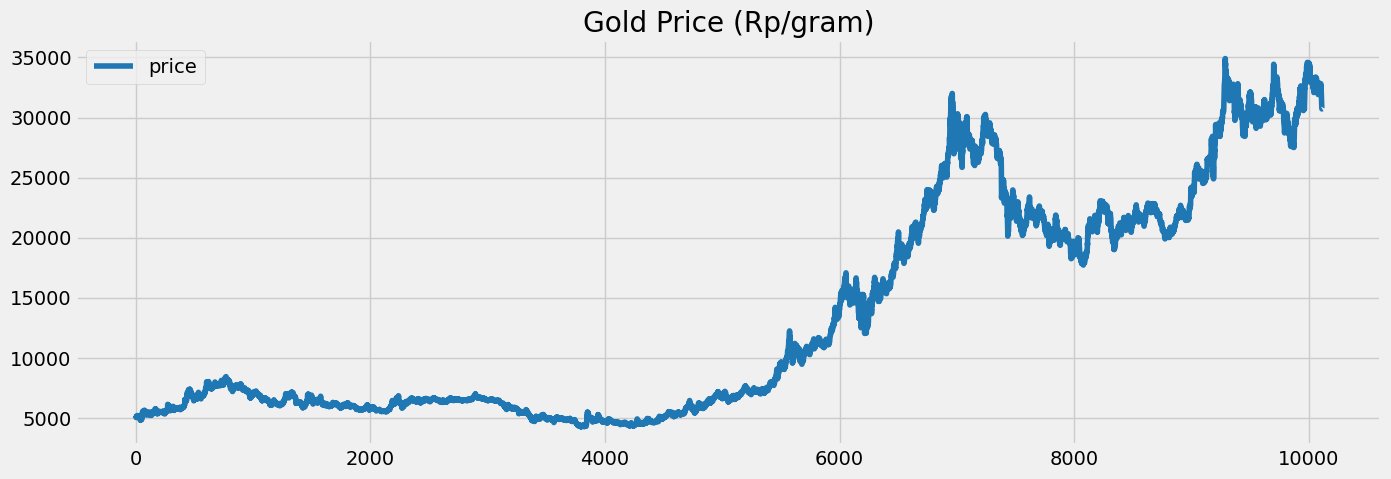

In [6]:
df.plot(
    style="-",
    figsize=(15, 5),
    color=color_pal[0],
    title="Gold Price (Rp/gram)"
)
plt.show()

In [7]:
train = pd.read_csv(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\train.csv')
test = pd.read_csv(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\test.csv')

In [8]:
train.head()

,date,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7
0,1985-12-19,5501.4588,3,4,12,1985,353,19,51,5404.3643,5422.9389,5379.8796,5361.3050,5498.9259,5529.3207,5205.9538,5373.487043,5455.134873,32.116182,64.521595,5422.9389,5327.5330
1,1985-12-20,5497.2373,4,4,12,1985,354,20,51,5501.4588,5404.3643,5422.9389,5365.5265,5501.4588,5536.9194,5158.6730,5394.715157,5456.710900,56.251879,65.072512,5501.4588,5327.5330
2,1985-12-23,5531.8536,0,4,12,1985,357,23,52,5497.2373,5501.4588,5404.3643,5379.8796,5513.2790,5547.0510,5104.6378,5418.958629,5458.737220,58.975658,65.365586,5501.4588,5361.3050
3,1985-12-24,5485.4171,1,4,12,1985,358,24,52,5531.8536,5497.2373,5501.4588,5422.9389,5575.7572,5559.7155,5118.9909,5443.322714,5461.270120,65.998538,66.708949,5531.8536,5365.5265
4,1985-12-25,5485.4171,2,4,12,1985,359,25,52,5485.4171,5531.8536,5497.2373,5404.3643,5593.4875,5548.7396,5036.2495,5460.449943,5462.255137,57.447273,66.844442,5531.8536,5379.8796


In [9]:
train = train[['date', 'price']]
train.columns = ['ds', 'y']
train.head()

,ds,y
0,1985-12-19,5501.4588
1,1985-12-20,5497.2373
2,1985-12-23,5531.8536
3,1985-12-24,5485.4171
4,1985-12-25,5485.4171


In [10]:
test = test[['date', 'price']]
test.columns = ['ds', 'y']
test.head()

,ds,y
0,2022-05-16,30555.2170
1,2022-05-17,30816.9500
2,2022-05-18,30574.6359
3,2022-05-19,31137.7840
4,2022-05-20,30972.3012


In [11]:
train['ds'] = pd.to_datetime(train['ds'])
test['ds'] = pd.to_datetime(test['ds'])

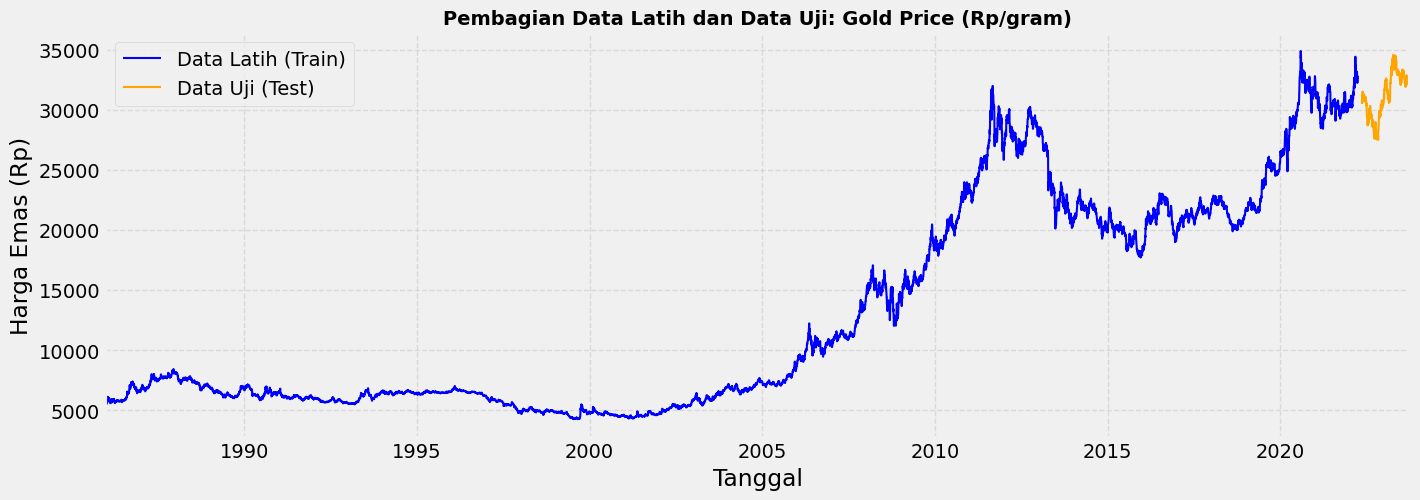

In [12]:
fig, axs = plt.subplots(figsize=(15, 5))

train.plot(x='ds', y='y', ax=axs, label='Data Latih (Train)', color='blue', linewidth=1.5)
test.plot(x='ds', y='y', ax=axs, label='Data Uji (Test)', color='orange', linewidth=1.5)

plt.title("Pembagian Data Latih dan Data Uji: Gold Price (Rp/gram)", fontsize=14, fontweight='bold')
plt.xlabel("Tanggal")
plt.ylabel("Harga Emas (Rp)")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [13]:
train['y_log'] = np.log(train['y'])
test['y_log'] = np.log(test['y'])

df_train_prophet = train[['ds', 'y_log']].rename(columns={'y_log': 'y'})
df_test_prophet = test[['ds', 'y_log']].rename(columns={'y_log': 'y'})

In [ ]:
# param_grid = {
#     'changepoint_prior_scale' : [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5],
#     'seasonality_prior_scale' : [0.01, 0.1, 1.0, 5.0, 10.0, 20.0],
#     'holidays_prior_scale' : [0.01, 0.1, 1.0, 10.0],
#     'changepoint_range' : [0.8, 0.85, 0.9, 0.95]
# }

# all_params = [dict(zip(param_grid.keys(), v))for v in itertools.product(*param_grid.values())]
# rmses = []

# print(f"Mulai menguji {len(all_params)} kombinasi parameter...\n")

# for i, params in enumerate(all_params):
#     m = Prophet(
#         yearly_seasonality=True,
#         weekly_seasonality=True,
#         daily_seasonality=False,
#         seasonality_mode='additive',
#         **params
#     )
#     m.add_country_holidays(country_name='ID')
#     m.add_country_holidays(country_name='US')

#     m.fit(train[['ds', 'y']])
#     y_pred = m.predict(test[['ds']])
#     rmse_score = np.sqrt(mean_squared_error(test['y'], y_pred['yhat']))
#     rmses.append(rmse_score)

#     print(f"Kombinasi {i+1} | {params} --> RMSE: {rmse_score:.2f}")

# best_params = all_params[np.argmin(rmses)]
# print("\n" + "="*40)
# print(" KESIMPULAN GRID SEARCH ")
# print(f"Parameter Terbaik : {best_params}")
# print(f"RMSE Terendah     : {min(rmses):.2f}")
# print("="*40)

Mulai menguji 672 kombinasi parameter...



Changing country holidays from 'ID' to 'US'.
04:04:38 - cmdstanpy - INFO - Chain [1] start processing
04:04:39 - cmdstanpy - INFO - Chain [1] done processing
Changing country holidays from 'ID' to 'US'.


Kombinasi 1 | {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 0.01, 'changepoint_range': 0.8} --> RMSE: 2135.85


04:04:40 - cmdstanpy - INFO - Chain [1] start processing
04:04:41 - cmdstanpy - INFO - Chain [1] done processing
Changing country holidays from 'ID' to 'US'.


Kombinasi 2 | {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 0.01, 'changepoint_range': 0.85} --> RMSE: 2150.69


...

Kombinasi 670 | {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 20.0, 'holidays_prior_scale': 10.0, 'changepoint_range': 0.85} --> RMSE: 2972.52


05:12:58 - cmdstanpy - INFO - Chain [1] start processing
05:13:04 - cmdstanpy - INFO - Chain [1] done processing
Changing country holidays from 'ID' to 'US'.


Kombinasi 671 | {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 20.0, 'holidays_prior_scale': 10.0, 'changepoint_range': 0.9} --> RMSE: 5375.26


05:13:06 - cmdstanpy - INFO - Chain [1] start processing
05:13:13 - cmdstanpy - INFO - Chain [1] done processing


Kombinasi 672 | {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 20.0, 'holidays_prior_scale': 10.0, 'changepoint_range': 0.95} --> RMSE: 1725.55

 KESIMPULAN GRID SEARCH 
Parameter Terbaik : {'changepoint_prior_scale': 0.005, 'seasonality_prior_scale': 20.0, 'holidays_prior_scale': 0.01, 'changepoint_range': 0.8}
RMSE Terendah     : 1482.56


In [15]:
print(f"Parameter Terbaik : {best_params}")
print(f"RMSE Terendah     : {min(rmses):.2f}")

Parameter Terbaik : {'changepoint_prior_scale': 0.005, 'seasonality_prior_scale': 20.0, 'holidays_prior_scale': 0.01, 'changepoint_range': 0.8}
RMSE Terendah     : 1482.56


Parameter Terbaik : {'changepoint_prior_scale': 0.005, 'seasonality_prior_scale': 20.0, 'holidays_prior_scale': 0.01, 'changepoint_range': 0.8}
RMSE Terendah     : 1482.56

In [20]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.005,
    seasonality_prior_scale=20.0,
    holidays_prior_scale=0.01,
    changepoint_range=0.8
)

model.add_country_holidays(country_name='US')
model.add_country_holidays(country_name='ID')

model.fit(train)


Changing country holidays from 'US' to 'ID'.
05:19:17 - cmdstanpy - INFO - Chain [1] start processing
05:19:20 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# y_pred_log = m.predict(df_test_prophet)
# y_pred = np.exp(y_pred_log['yhat'])

In [ ]:
# y_pred.head()

0    31228.810853
1    31164.017626
2    31169.228417
3    31170.690341
4    31183.676176
Name: yhat, dtype: float64

In [21]:
y_pred = model.predict(test)
y_pred.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Ascension Day,Ascension Day_lower,Ascension Day_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Day of Silence,Day of Silence_lower,Day of Silence_upper,Eid al-Adha,Eid al-Adha_lower,Eid al-Adha_upper,Eid al-Fitr,Eid al-Fitr_lower,Eid al-Fitr_upper,Eid al-Fitr (observed),Eid al-Fitr (observed)_lower,Eid al-Fitr (observed)_upper,Eid al-Fitr Second Day,Eid al-Fitr Second Day_lower,Eid al-Fitr Second Day_upper,General Election Day,General Election Day_lower,General Election Day_upper,Good Friday,Good Friday_lower,Good Friday_upper,Independence Day,Independence Day_lower,Independence Day_upper,International Labor Day,International Labor Day_lower,International Labor Day_upper,Islamic New Year,Islamic New Year_lower,Islamic New Year_upper,Isra' and Mi'raj,Isra' and Mi'raj_lower,Isra' and Mi'raj_upper,Legislative Election Day,Legislative Election Day_lower,Legislative Election Day_upper,Local Election Day,Local Election Day_lower,Local Election Day_upper,Lunar New Year,Lunar New Year_lower,Lunar New Year_upper,New Year's Day,New Year's Day_lower,New Year's Day_upper,Pancasila Day,Pancasila Day_lower,Pancasila Day_upper,Presidential Election Day,Presidential Election Day_lower,Presidential Election Day_upper,Prophet's Birthday,Prophet's Birthday_lower,Prophet's Birthday_upper,Vesak Day,Vesak Day_lower,Vesak Day_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,holidays_lower,holidays_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-05-16,30220.516097,28908.969737,32122.000152,30220.516097,30220.516097,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,112.960108,112.960108,112.960108,331.778851,331.778851,331.778851,112.960108,112.960108,112.960108,248.628140,248.628140,248.628140,-29.809396,-29.809396,-29.809396,0.0,0.0,0.0,30552.294948
1,2022-05-17,30224.943068,28799.470158,32073.089615,30224.943068,30224.943068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,215.783345,215.783345,215.783345,0.000000,0.000000,0.000000,247.510571,247.510571,247.510571,-31.727226,-31.727226,-31.727226,0.0,0.0,0.0,30440.726413
2,2022-05-18,30229.370040,28762.247120,32180.982001,30229.370040,30229.370040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,213.635525,213.635525,213.635525,0.000000,0.000000,0.000000,247.357290,247.357290,247.357290,-33.721765,-33.721765,-33.721765,0.0,0.0,0.0,30443.005565
3,2022-05-19,30233.797012,28804.394369,32088.687602,30233.797012,30233.797012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,210.811148,210.811148,210.811148,0.000000,0.000000,0.000000,246.569091,246.569091,246.569091,-35.757943,-35.757943,-35.757943,0.0,0.0,0.0,30444.608160
4,2022-05-20,30238.223983,28787.201187,32089.756194,30238.223983,30238.223983,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,211.006033,211.00

In [22]:
rmse = np.sqrt(mean_squared_error(test['y'], y_pred['yhat']))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 1498.93


In [121]:
# rmse = np.sqrt(mean_squared_error(test['y'], y_pred['yhat']))
# print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 1689.43

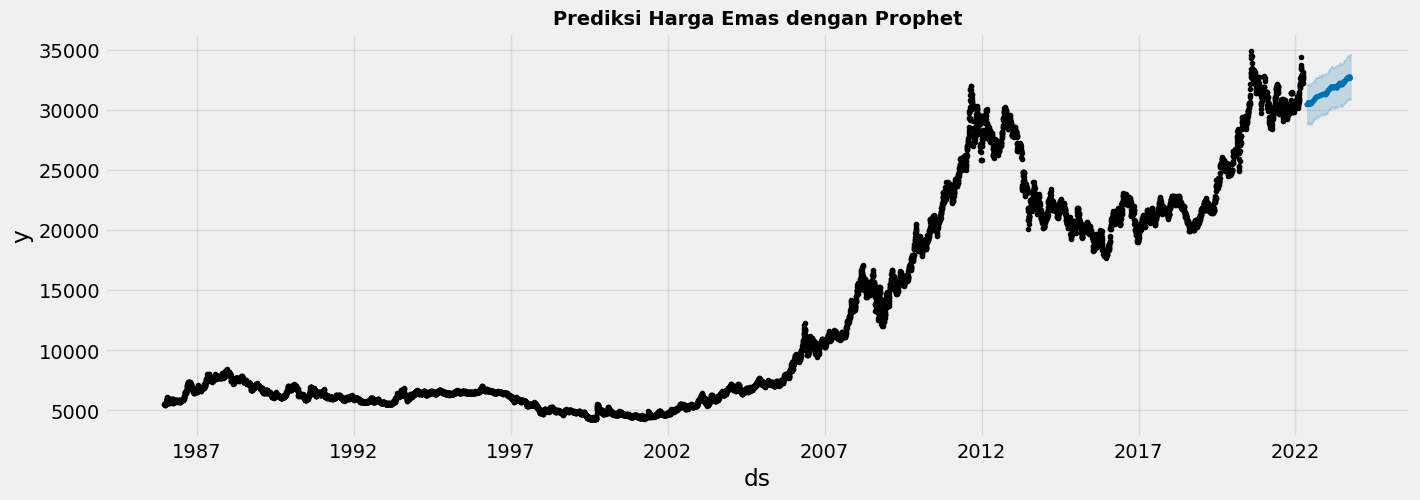

In [23]:
fig, axs = plt.subplots(figsize=(15, 5))
fig = model.plot(y_pred, ax=axs)
axs.set_title("Prediksi Harga Emas dengan Prophet", fontsize=14, fontweight='bold')
plt.show()

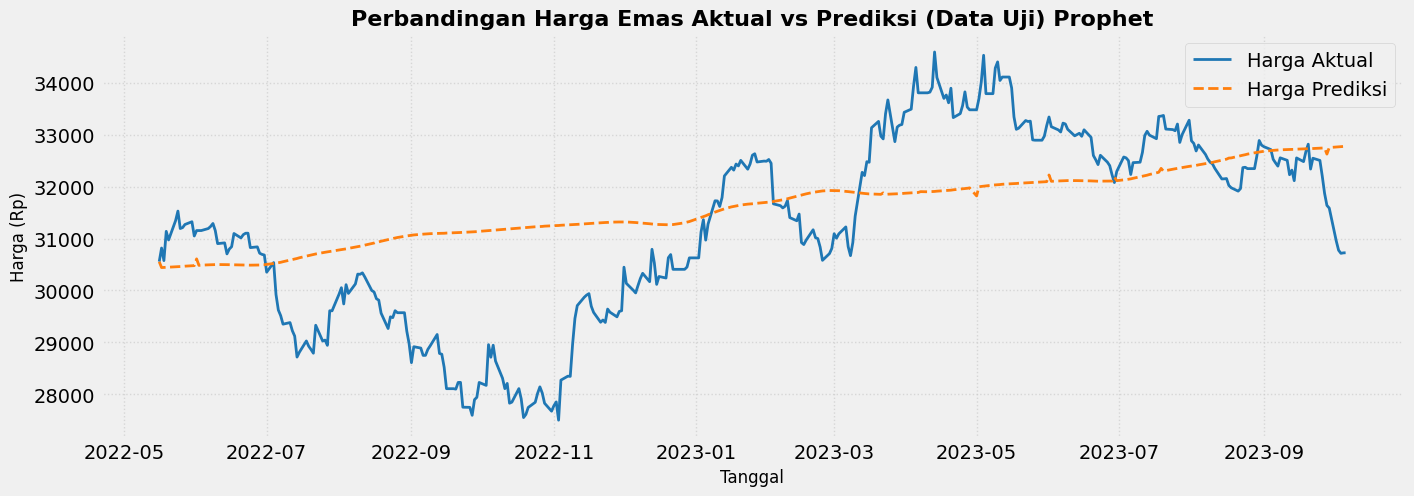

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(test['ds'], test['y'], label='Harga Aktual', color=color_pal[0], linewidth=2)

plt.plot(test['ds'], y_pred['yhat'], label='Harga Prediksi', color=color_pal[1], linewidth=2, linestyle='--')

plt.title('Perbandingan Harga Emas Aktual vs Prediksi (Data Uji) Prophet', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (Rp)', fontsize=12)

plt.legend(loc='best') 
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

Membedah Jalan Pikiran Prophet...


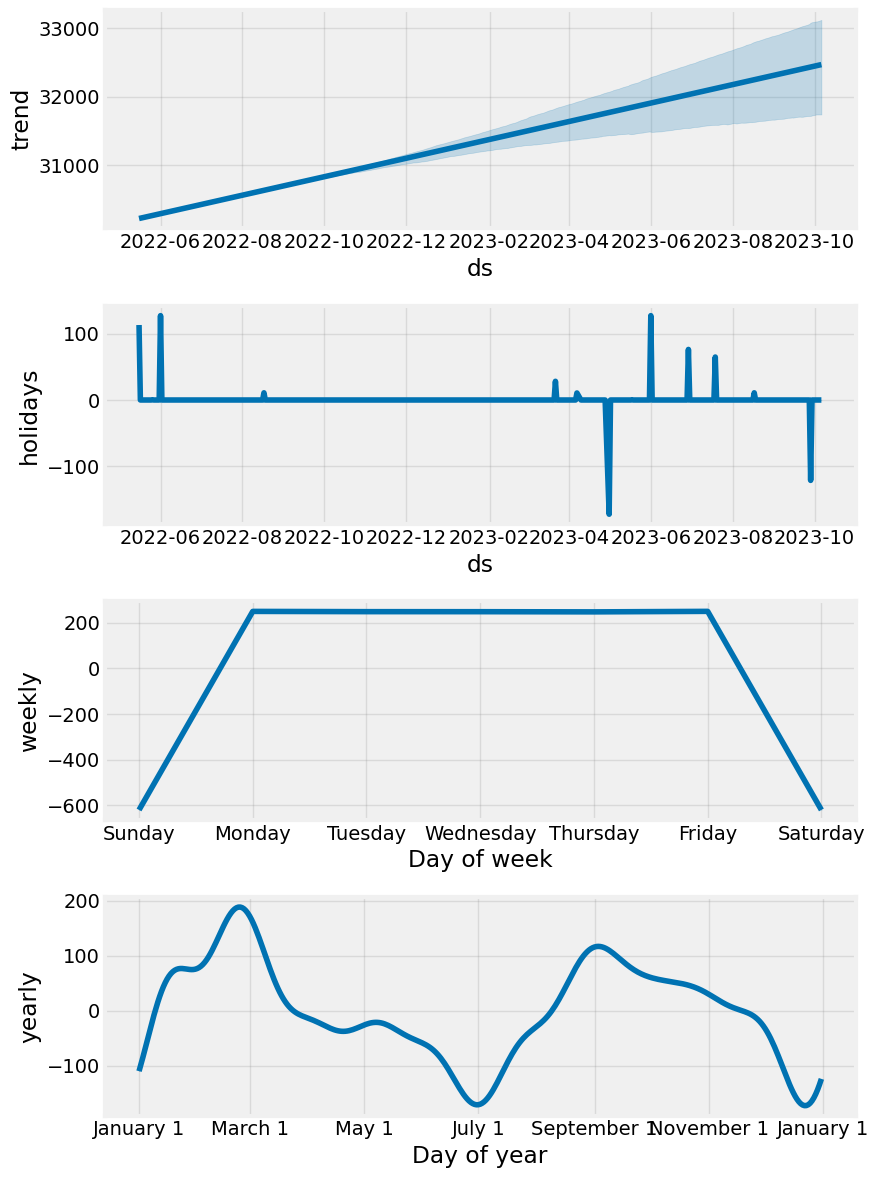

In [28]:
print("Membedah Jalan Pikiran Prophet...")

# Baris ajaib untuk mengeluarkan grafik komponen
fig_komponen = model.plot_components(y_pred)

# Tampilkan ke layar
plt.show()

In [31]:
with open(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\artifacts\prophet.json', 'w') as fout:
    json.dump(model_to_json(model), fout)

print("Model Prophet berhasil disimpan dalam format JSON!")

Model Prophet berhasil disimpan dalam format JSON!


In [1]:
import pandas as pd
import numpy as np
import json
from prophet.serialize import model_from_json
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [4]:
with open(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\artifacts\prophet.json', 'r') as f:
    json_string = json.load(f)
    model_prophet = model_from_json(json_string)

test_df = pd.read_csv(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\test.csv')
test_df.head()

,date,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7
0,2022-05-16,30555.2170,0,2,5,2022,136,16,20,30589.8333,31020.4263,31272.0277,31423.1574,33151.4395,31451.8636,31939.0247,31343.913814,32296.895327,456.695397,747.730819,31953.3778,30589.8333
1,2022-05-17,30816.9500,1,2,5,2022,137,17,20,30555.2170,30589.8333,31020.4263,31363.2121,33151.4395,31972.7967,32082.5557,31144.176557,32228.901033,451.433943,809.848707,31785.3621,30555.2170
2,2022-05-18,30574.6359,2,2,5,2022,138,18,20,30816.9500,30555.2170,30589.8333,31272.0277,33164.1040,31975.3296,32082.5557,31005.831971,32161.891757,361.648857,841.195697,31423.1574,30555.2170
3,2022-05-19,31137.7840,3,2,5,2022,139,19,20,30574.6359,30816.9500,30555.2170,31020.4263,32920.1013,31989.6827,32072.4241,30884.614614,32094.629190,340.013083,885.104997,31363.2121,30555.2170
4,2022-05-20,30972.3012,4,2,5,2022,140,20,20,31137.7840,30574.6359,30816.9500,30589.8333,32821.3182,32085.0886,32129.8365,30852.410600,32044.871777,294.797353,895.833827,31272.0277,30555.2170


In [6]:
test_df['ds'] = pd.to_datetime(test_df['date'])
test_df['y'] = test_df['price']
test_df = test_df[['ds', 'y']]
test_df.head()

,ds,y
0,2022-05-16,30555.2170
1,2022-05-17,30816.9500
2,2022-05-18,30574.6359
3,2022-05-19,31137.7840
4,2022-05-20,30972.3012


In [7]:
future_test = test_df[['ds']]
forecast = model_prophet.predict(future_test)

In [8]:
y_true = test_df['y'].values
y_pred = forecast['yhat'].values

In [9]:
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

In [10]:
print("-" * 30)
print("📊 HASIL EVALUASI MODEL PROPHET")
print("-" * 30)
print(f"MAE  : Rp {mae:,.2f}")
print(f"RMSE : Rp {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")
print("-" * 30)

------------------------------
📊 HASIL EVALUASI MODEL PROPHET
------------------------------
MAE  : Rp 1,201.87
RMSE : Rp 1,498.93
MAPE : 3.96%
------------------------------
